# Maximum Likelihood Estimation

## Learning Objectives

By the end of this notebook you will be able to:

1. Define the **likelihood function** $L(\theta) = \prod f(x_i; \theta)$ and the **log-likelihood** $\ell(\theta)$.
2. Derive MLE estimators analytically for simple distributions.
3. Implement a **from-scratch MLE** using numerical optimisation (gradient ascent in NumPy).
4. Use `scipy.optimize.minimize` and `scipy.stats.fit()` for professional MLE.
5. Explain **Fisher information** and how it relates to the variance of the MLE.
6. Understand the asymptotic properties: MLE is consistent, asymptotically Normal, and efficient.

## Prerequisites

- [01_point_estimation.ipynb](01_point_estimation.ipynb) — bias, variance, MSE, efficiency, Cramér-Rao bound
- [02_method_of_moments.ipynb](02_method_of_moments.ipynb) — MoM as a simpler alternative
- [Math foundations](../00_prerequisites/02_math_foundations.ipynb) — derivatives, logarithms

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Likelihood Function

Given i.i.d. observations $x_1, \dots, x_n$ from a distribution with PDF $f(x; \theta)$, the **likelihood function** treats the data as fixed and the parameter as variable:

> **Definition.** The *likelihood function* is:
>
> $$L(\theta) = \prod_{i=1}^n f(x_i; \theta)$$
>
> The *log-likelihood* is:
>
> $$\ell(\theta) = \ln L(\theta) = \sum_{i=1}^n \ln f(x_i; \theta)$$

The **maximum likelihood estimator** (MLE) is the parameter value that maximises $L(\theta)$ (equivalently, $\ell(\theta)$):

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \ell(\theta)$$

**Why log?** Products of many small numbers underflow to zero numerically. The log turns products into sums, which are both numerically stable and easier to differentiate.

### Intuition

The likelihood asks: "Given a parameter value $\theta$, how probable is the data we observed?" The MLE picks the $\theta$ that makes the observed data *most probable*.

---

## 2. Analytical MLE: The Exponential Distribution

For $X \sim \text{Exponential}(\lambda)$ with PDF $f(x; \lambda) = \lambda e^{-\lambda x}$:

$$\ell(\lambda) = \sum_{i=1}^n \left[\ln \lambda - \lambda x_i\right] = n \ln \lambda - \lambda \sum x_i$$

To find the maximum, differentiate and set to zero:

$$\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum x_i = 0 \quad \Rightarrow \quad \hat{\lambda}_{\text{MLE}} = \frac{n}{\sum x_i} = \frac{1}{\bar{x}}$$

The MLE for the rate is the inverse of the sample mean — exactly what you'd intuitively guess.

Let's verify this by scanning the log-likelihood and finding the peak numerically:

True λ = 2.0
MLE λ̂  = 2.3926


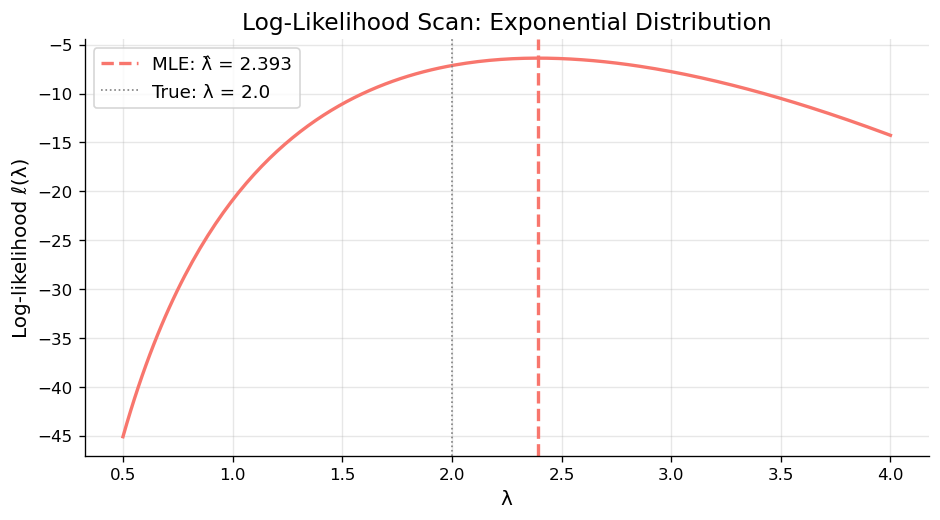

In [ ]:
# Generate exponential data and find MLE
true_lambda = 2.0
data = rng.exponential(scale=1 / true_lambda, size=50)

# Analytical MLE
lambda_mle = 1 / np.mean(data)
print(f"True λ = {true_lambda}")
print(f"MLE λ̂  = {lambda_mle:.4f}")

# Scan the log-likelihood (pedagogical — shows the shape)
lambdas = np.linspace(0.5, 4.0, 200)
log_lik = np.array([np.sum(np.log(lam) - lam * data) for lam in lambdas])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lambdas, log_lik, linewidth=2)
ax.axvline(
    lambda_mle,
    color="#F8766D",
    linewidth=2,
    linestyle="--",
    label=f"MLE: λ̂ = {lambda_mle:.3f}",
)
ax.axvline(
    true_lambda,
    color="grey",
    linewidth=1,
    linestyle=":",
    label=f"True: λ = {true_lambda}",
)
ax.set_xlabel("λ")
ax.set_ylabel("Log-likelihood ℓ(λ)")
ax.set_title("Log-Likelihood Scan: Exponential Distribution")
ax.legend()
plt.tight_layout()
plt.show()

The log-likelihood is a smooth, concave curve with a single peak at the MLE. The curvature at the peak relates to the **precision** of the estimate — a sharper peak means more certainty. We'll formalise this with Fisher information in Section 5.

---

## 3. Analytical MLE: The Normal Distribution

For $X \sim \mathcal{N}(\mu, \sigma^2)$:

$$\ell(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum(x_i - \mu)^2$$

Setting $\partial\ell/\partial\mu = 0$ and $\partial\ell/\partial\sigma^2 = 0$:

$$\hat{\mu}_{\text{MLE}} = \bar{x}, \qquad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum(x_i - \bar{x})^2$$

Note: the MLE for $\sigma^2$ divides by $n$ (biased), just like MoM. The MLE is **not always unbiased** — but it is asymptotically unbiased and has the lowest asymptotic variance.

---

## 4. Numerical MLE: From-Scratch Optimisation

Many distributions don't have closed-form MLEs (e.g., Gamma, Beta, mixture models). In those cases, we maximise $\ell(\theta)$ **numerically**.

### From scratch: gradient ascent for Exponential

The score function (gradient of log-likelihood) is:

$$\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum x_i$$

Gradient ascent: $\lambda_{t+1} = \lambda_t + \eta \cdot \frac{d\ell}{d\lambda}\big|_{\lambda_t}$

Gradient ascent MLE: λ̂ = 2.2333
Analytical MLE:      λ̂ = 2.3926


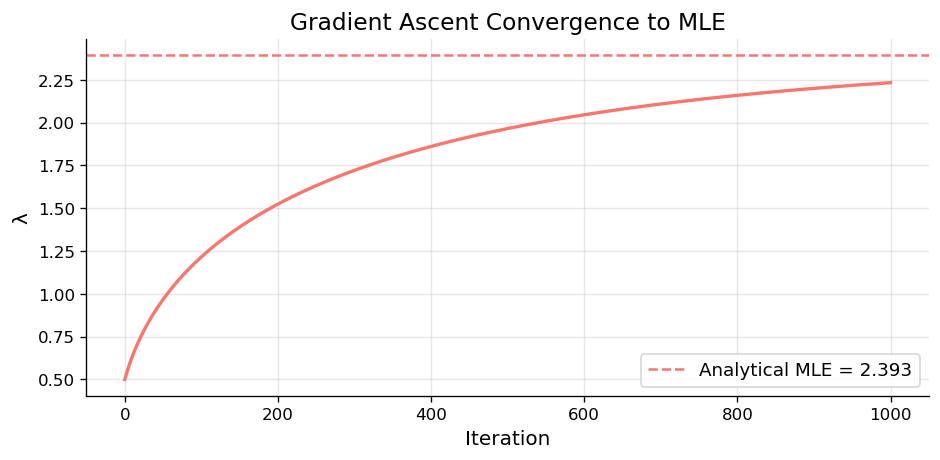

In [ ]:
# Stage 2: FROM SCRATCH — gradient ascent MLE
def mle_exponential_gradient(data, lr=0.0001, n_steps=500, init=1.0):
    """Find MLE for Exponential(λ) via gradient ascent on ℓ(λ)."""
    n = len(data)
    lam = init
    history = [lam]

    for _ in range(n_steps):
        # Score: dℓ/dλ = n/λ - Σxᵢ
        gradient = n / lam - np.sum(data)
        lam = lam + lr * gradient
        lam = max(lam, 1e-6)  # keep positive
        history.append(lam)

    return lam, history


lam_gd, history = mle_exponential_gradient(data, lr=0.0002, n_steps=1000, init=0.5)
print(f"Gradient ascent MLE: λ̂ = {lam_gd:.4f}")
print(f"Analytical MLE:      λ̂ = {lambda_mle:.4f}")

# Plot convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, linewidth=2)
ax.axhline(
    lambda_mle,
    color="#F8766D",
    linestyle="--",
    linewidth=1.5,
    label=f"Analytical MLE = {lambda_mle:.3f}",
)
ax.set_xlabel("Iteration")
ax.set_ylabel("λ")
ax.set_title("Gradient Ascent Convergence to MLE")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Stage 3: PROFESSIONAL — scipy.optimize.minimize (we minimise -ℓ)
def neg_log_lik_exp(lam, data):
    """Negative log-likelihood for Exponential(λ)."""
    if lam <= 0:
        return np.inf
    return -np.sum(np.log(lam) - lam * data)


result = optimize.minimize_scalar(
    neg_log_lik_exp, bounds=(0.01, 10), args=(data,), method="bounded"
)
print(f"scipy MLE:      λ̂ = {result.x:.4f}")
print(f"Analytical MLE: λ̂ = {lambda_mle:.4f}")
print(f"Gradient ascent: λ̂ = {lam_gd:.4f}")

scipy MLE:      λ̂ = 2.3926
Analytical MLE: λ̂ = 2.3926
Gradient ascent: λ̂ = 2.2333


All three approaches converge to the same answer. In practice, `scipy.optimize.minimize` handles multi-parameter problems, constraints, and convergence automatically. But understanding the gradient ascent version shows you exactly what the optimizer does.

---

## 5. Fisher Information and Estimator Precision

The **curvature** of the log-likelihood at the MLE tells us how precisely the parameter is estimated.

> **Definition.** The **Fisher information** is:
>
> $$I(\theta) = -E\left[\frac{\partial^2 \ell}{\partial\theta^2}\right] = E\left[\left(\frac{\partial \ell}{\partial\theta}\right)^2\right]$$

For $n$ observations: $I_n(\theta) = n \cdot I_1(\theta)$.

The **Cramér-Rao bound** (from notebook 01) says:

$$\text{Var}(\hat{\theta}) \geq \frac{1}{I_n(\theta)}$$

The MLE achieves this bound **asymptotically** — meaning for large $n$, the MLE is the most efficient estimator.

### Practical consequence: reading uncertainty from the log-likelihood

Near the MLE, $\ell(\theta)$ is approximately parabolic:

$$\ell(\theta) \approx \ell(\hat{\theta}) - \frac{1}{2}I_n(\hat{\theta})(\theta - \hat{\theta})^2$$

A 1-sigma confidence region corresponds to $\ell(\theta) = \ell(\hat{\theta}) - \frac{1}{2}$. This is how modern fitting software extracts parameter uncertainties.

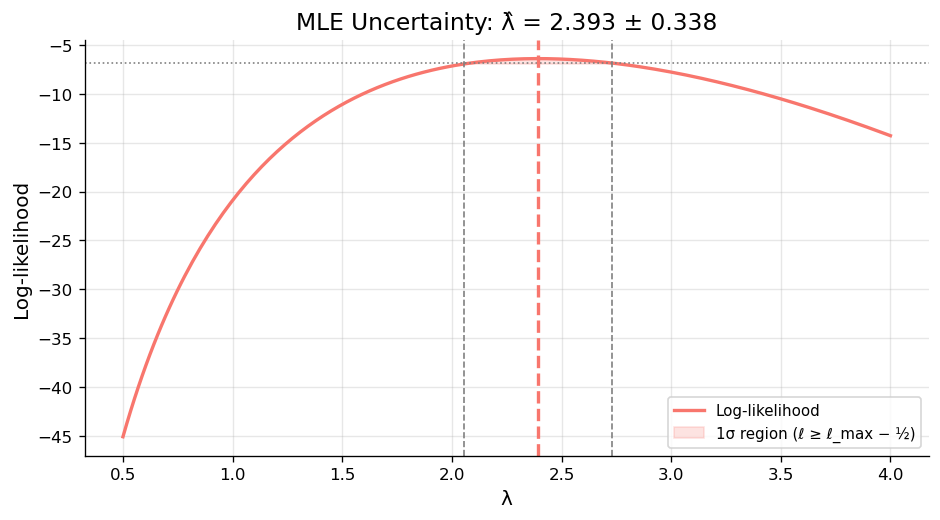

In [ ]:
# Uncertainty from the log-likelihood curvature
# For Exponential: I(λ) = n/λ², so SE(λ̂) = λ̂/√n
se_analytical = lambda_mle / np.sqrt(len(data))

# Numerical: find where ℓ drops by 1/2 from the peak
peak_ll = np.sum(np.log(lambda_mle) - lambda_mle * data)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lambdas, log_lik, linewidth=2, label="Log-likelihood")
ax.axhline(peak_ll - 0.5, color="grey", linestyle=":", linewidth=1)
ax.fill_between(
    lambdas,
    log_lik,
    peak_ll - 0.5,
    where=(log_lik >= peak_ll - 0.5),
    alpha=0.2,
    color="#F8766D",
    label="1σ region (ℓ ≥ ℓ_max − ½)",
)
ax.axvline(lambda_mle, color="#F8766D", linewidth=2, linestyle="--")
ax.axvline(lambda_mle - se_analytical, color="grey", linewidth=1, linestyle="--")
ax.axvline(lambda_mle + se_analytical, color="grey", linewidth=1, linestyle="--")

ax.set_xlabel("λ")
ax.set_ylabel("Log-likelihood")
ax.set_title(f"MLE Uncertainty: λ̂ = {lambda_mle:.3f} ± {se_analytical:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The shaded region shows the 1-sigma interval around the MLE. The width of this region is determined by the curvature of the log-likelihood — a sharper peak means a more precise estimate.

---

## 6. Asymptotic Properties of the MLE

Under regularity conditions, the MLE has three key properties as $n \to \infty$:

| Property                 | Statement                                                                       |
|--------------------------|---------------------------------------------------------------------------------|
| **Consistency**          | $\hat{\theta}_{\text{MLE}} \xrightarrow{P} \theta$                              |
| **Asymptotic Normality** | $\sqrt{n}(\hat{\theta} - \theta) \xrightarrow{d} \mathcal{N}(0, 1/I_1(\theta))$ |
| **Efficiency**           | Achieves the Cramér-Rao bound asymptotically                                    |

In words: with enough data, the MLE is approximately unbiased, Normally distributed, and has the smallest possible variance. This is why MLE is the **default estimation method** in statistics.

---

## Exercises

**Exercise 3.1 (Analytical MLE).** Derive the MLE for $p$ in $\text{Binomial}(n, p)$ given $k$ successes. Show that $\hat{p} = k/n$.

**Exercise 3.2 (Numerical MLE).** For $X \sim \text{Gamma}(\alpha, \beta)$, write the log-likelihood and use `scipy.optimize.minimize` to find the MLE. Compare with `scipy.stats.gamma.fit()` and with the MoM estimator from notebook 02.

**Exercise 3.3 (From-scratch optimiser).** Implement gradient ascent for the Normal MLE (two parameters: $\mu$ and $\sigma^2$). Compute the gradients analytically and iterate until convergence.

**Exercise 3.4 (Fisher information).** For $X \sim \text{Poisson}(\lambda)$, compute the Fisher information $I(\lambda)$ analytically. What is the Cramér-Rao bound for estimating $\lambda$? Verify by simulation.

**Exercise 3.5 (Asymptotic normality).** Generate 10,000 samples of size $n = 50$ from $\text{Exponential}(\lambda = 2)$. For each, compute $\hat{\lambda}_{\text{MLE}}$. Plot the histogram of $\sqrt{n}(\hat{\lambda} - \lambda)$ and overlay $\mathcal{N}(0, \lambda^2)$. Does the CLT approximation hold?

**Exercise 3.6 (Challenge — mixture model).** Implement MLE for a mixture of two Gaussians: $f(x) = \pi \cdot \mathcal{N}(x; \mu_1, \sigma_1^2) + (1-\pi) \cdot \mathcal{N}(x; \mu_2, \sigma_2^2)$. Use `scipy.optimize.minimize` with 5 parameters. (*Hint:* the EM algorithm is easier, but direct optimisation works too.)

---

## Key Takeaways

1. The **likelihood function** $L(\theta) = \prod f(x_i; \theta)$ asks: how probable is the data under this parameter?
2. The **MLE** maximises $L(\theta)$ — we work with $\ell(\theta) = \log L(\theta)$ for numerical stability.
3. For simple distributions (Exponential, Normal, Binomial), the MLE has a **closed-form** solution found by setting the score to zero.
4. For complex distributions, we use **numerical optimisation** — from scratch with gradient ascent, or professionally with `scipy.optimize`.
5. **Fisher information** measures the curvature of the log-likelihood and gives the theoretical precision of the MLE.
6. The MLE is **consistent**, **asymptotically Normal**, and **efficient** — the gold standard of point estimation.

**Next:** [04_confidence_intervals.ipynb](04_confidence_intervals.ipynb) — How to go from a point estimate to an interval that quantifies uncertainty.

In [6]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BiasVarianceDartboard@2026-03-19@16-26-55.gif
  Cleaned up local temp render files (kept media/jupyter/).
